# S7-4 クレジットスプレッド分析（実データ）

## 学習目標

- 社債スプレッドの4指標（OAS・G-spread・I-spread・ASW）の定義と使い分けを説明できる
- 格付・セクター・年限がスプレッド構造をどう決めるかを整理できる
- 信用プレミアムと流動性プレミアムの分解がなぜ難しいかを言語化できる
- `bondlab` の債券・ゼロカーブを使い、G-spread / I-spread / Zスプレッド計算機を自作できる
- スプレッド指標間の整合性（G と I の差、Z と G の大小）を自作計算の内部検証として確認できる
- 合成の投資適格（IG）/ ハイイールド（HY）スプレッド時系列から景気局面を判定し、現在水準の割高・割安を論じられる

S7 のクレジット層のうち、本ノートはキャッシュ債のスプレッド分解と相対価値に絞ります。
ハザードモデル・CDS（S7-1〜S7-3）とは独立に読めます。

## 実務での位置づけ（ファンドはどう稼ぐか）

キャッシュ債のスプレッド指標は、クレジット運用のあらゆる意思決定の共通言語です。docs の枠組みでは、社債を扱う運用会社とクレジットヘッジファンドが、格付・セクター・年限で切ったスプレッドの相対価値を見て銘柄を選びます。同じ発行体でも「どの無リスク基準から、どの割引方法で測るか」で見え方が変わるため、対国債の直感が欲しければ G-spread、スワップでヘッジする前提なら I-spread、現物とスワップをパッケージで持つなら ASW、カーブ形状を正した精緻な水準なら Z スプレッド／OAS、と使い分けます。指数運用やクレジットの銘柄選択では OAS が横断比較の物差しになり、同格付・同年限のなかで OAS が広い（割安な）銘柄を拾い、狭い銘柄を売る、という**相対価値**が超過リターンの源泉です。

収益の実体は、スプレッドが生むキャリーと、時間経過でカーブを滑り降りる**ロールダウン**の合成です。右肩上がりのクレジットカーブでは、5年債を持って1年経つと4年地点のスプレッドまで縮み、価格が上がります。ファンドは「キャリー＋ロールダウン」を年限・格付ごとに比較し、単位リスクあたりの取り分が厚い場所を選びます。ここで難しいのは、観測スプレッドに信用プレミアムと流動性プレミアムが混ざっていることで、割安に見える銘柄が実は流動性の対価だった、という取り違えが損失につながります。指標間の整合性（G と I の差がスワップスプレッドに一致するか、Z と G の大小関係が妥当か）を突き合わせるのは、この分解の妥当性を保つ実務の作法です。

合成 IG／HY スプレッドの時系列から景気局面を読むのは、**マクロ**寄りのクレジット判断です。スプレッドが歴史的にタイトなら信用エクスポージャーを軽くし、ワイドなら拾う、という水準観でポートフォリオのベータ（市場全体への感応度）を調整します。個別銘柄の相対価値（アルファ）と、市場全体の割高・割安（ベータ）を分けて管理することが、クレジット運用の基本構造です。


## 理論

### スプレッドとは何を測る量か

社債の利回りは、同年限の国債利回りより高くなります。この上乗せ分（スプレッド）は、
デフォルト・格下げ・流動性の劣後に対する対価です。ただし「どの無リスク基準から、
どの割引方法で測るか」でスプレッドの定義は変わります。実務では次の4種を使い分けます。

### 4指標の定義

記号：社債の利回り $y_{\text{corp}}$、同年限の国債利回り $y_{\text{govt}}$、
補間スワップレート $s_{\text{swap}}$、ゼロカーブ $z(t)$、キャッシュフロー $c_k$（時点 $t_k$）、
ダーティ価格 $P$。

- **G-spread（対国債スプレッド）**：社債の最終利回りと、同年限に補間した国債利回りの差。
  $$ \text{G-spread} = y_{\text{corp}} - y_{\text{govt}}(T) $$
  単一の利回り点どうしの引き算で、直感的だがカーブ形状を無視します。

- **I-spread（対スワップスプレッド）**：社債利回りと、同年限に補間したスワップレートの差。
  $$ \text{I-spread} = y_{\text{corp}} - s_{\text{swap}}(T) $$
  基準をスワップに替えたG-spreadです。両者の差はスワップスプレッド（スワップ−国債）に一致します。

- **アセットスワップスプレッド（ASW, asset swap spread）**：社債を「固定利付債＋金利スワップ」に
  組み替えるアセットスワップ・パッケージで、変動金利（LIBOR/OISなど）に上乗せして受け取る幅。
  パーパー方式では、社債を額面で買い、固定クーポンを払って変動＋ASWを受け取る構成にし、
  初期の価格差（額面−市場価格）を織り込んで
  $$ \text{ASW} \approx \frac{(100 - P_{\text{clean}}) + \text{固定脚PV} - \text{スワップ固定脚PV}}{\text{変動脚アニュイティ}} $$
  となります。実務ではスワップデスクが提示する「変動＋αで交換できる幅」で、I-spread に近い水準になります。

- **Zスプレッド（ゼロボラティリティスプレッド）**：ゼロカーブ全体に一定値 $Z$ を足して、
  割引現在価値を市場価格に一致させる定数。
  $$ P = \sum_k c_k \, e^{-(z(t_k) + Z)\, t_k} $$
  単一利回りではなくカーブ全体で割り引くため、カーブ形状の影響を正しく取り込みます。
  ASW と並んでカーブ全体を使う指標で、本ノートのスクラッチ実装の中心に据えます。

- **OAS（オプション調整スプレッド, option-adjusted spread）**：期限前償還条項などの
  オプション価値を金利モデルで評価して控除したうえで、残差を説明するスプレッド。
  オプションの無い債券では Zスプレッドと一致します。指数OASはこの意味のOASです。
  OASの実装は S6-4（コーラブルOAS）で扱い、本ノートはオプションの無い債券に絞ります。

### 4指標の使い分け表

求められる4指標（OAS / G-spread / I-spread / ASW）を整理し、実装で使う Zスプレッドを併記します。

| 指標 | 基準カーブ | 割引方法 | オプション調整 | 主な使いどころ |
|---|---|---|---|---|
| G-spread | 国債（同年限補間） | 単一利回り | なし | 対国債の直感的な相対価値、速報 |
| I-spread | スワップ（同年限補間） | 単一利回り | なし | スワップヘッジ前提のトレーダー目線 |
| ASW | スワップ（変動脚） | 期別割引（パッケージ） | なし | 現物＋スワップで持つ投資家の実受取幅 |
| Zスプレッド | ゼロカーブ全体 | 期別割引 | なし | カーブ形状を正した精緻な水準 |
| OAS | ゼロカーブ全体 | 期別割引 | あり | コーラブル債・指数、オプション込みの比較 |

大小関係の目安：オプションの無い普通社債では $\text{OAS} = Z\text{スプレッド}$、ASW は I-spread に近く、
$\text{G-spread} - \text{I-spread} = s_{\text{swap}}(T) - y_{\text{govt}}(T)$（スワップスプレッド）です。
Zスプレッドと G-spread の差はカーブ形状で決まり、順イールドで曲率が強いほど開きます
（どちらが大きいかは、G-spread の基準に単一のベンチマーク利回りを使うか補間パー利回りを使うかにも依存します）。

### 格付・セクター・年限による構造

スプレッドは主に3つの軸で構造化されます。

- **格付**：AAA から CCC へ下がるほどスプレッドは非線形に拡大します。投資適格（IG, BBB−以上）と
  ハイイールド（HY, BB+以下）の境界で流動性・投資家層が断絶するため、BBB と BB の間に段差が出ます。
- **セクター**：同じ格付でも、金融は景気・規制感応度が高く、公益はキャッシュフローが安定するため
  スプレッドが異なります。景気敏感（素材・エネルギー）はサイクルでスプレッドが大きく動きます。
- **年限**：クレジットカーブは通常右上がり（長いほどデフォルト累積確率が増える）ですが、
  ストレス時には短期のデフォルト懸念が跳ねて逆イールド化することがあります。

### 流動性プレミアムと、信用・流動性の分解が難しい理由

スプレッドは信用リスクだけでなく、売買のしにくさ（流動性）への対価も含みます。
発行額が小さい・取引頻度が低い銘柄は、同じ信用力でもスプレッドが上乗せされます。
しかし信用と流動性は独立ではありません。信用不安が高まると売り需要が集中して流動性も枯れるため、
両者は同時に悪化します。観測されるスプレッドは合計値のみで、
内訳（信用 $x$ ＋ 流動性 $y$、ただし $x+y$ しか見えない）を一意に切り分けられないのが本質的な難しさです。
CDS-bond ベーシス（社債スプレッドと同一発行体CDSの差）は、この分解の代理指標として使われます。

### 指数OASの構成方法

ICE BofA や Bloomberg の社債OAS指数は、多数の対象銘柄それぞれについてOASを計算し、
時価総額（または額面残高）で加重平均して1本の系列にします。構成の要点は次の通りです。

1. **銘柄選定**：格付・残存年限・最低発行額の基準を満たす銘柄を毎月末にリバランス。
2. **個別OAS算出**：各銘柄のキャッシュフローを、共通のスワップ／国債ベースのゼロカーブ＋OASで割引。
3. **加重集計**：時価総額加重でOASを平均し、指数レベルとする。

本ノートで扱う ICE BofA の指数値そのものは再配布不可のため、後半では現実的な水準・
景気連動を持つ**合成系列**を生成して分析します（生成コードと出所は該当セルに明記します）。

## スクラッチ実装

国債ゼロカーブ・スワップカーブ・社債を用意し、G-spread / I-spread / Zスプレッドを
自分で計算します。土台には `bondlab.bond.FixedRateBond` と
`bondlab.curve.bootstrap_par` を使います。

### 使用する自作関数

| 関数 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `future_cashflows(bond, settle)` | 債券, 決済日 | `(times, cfs)` | 決済日以降のCFと、決済日からの年数（ACT/365.25） |
| `dirty_from_curve(bond, settle, zc, s)` | 債券, 決済日, ゼロカーブ, 定数スプレッド | ダーティ価格 | ゼロカーブ＋定数 $s$ で期別割引した価格 |
| `g_spread(y_corp, y_govt_at_T)` | 社債利回り, 同年限国債利回り | G-spread | 対国債の単一利回り差 |
| `i_spread(y_corp, swap_at_T)` | 社債利回り, 補間スワップレート | I-spread | 対スワップの単一利回り差 |
| `z_spread(bond, clean, settle, zc)` | 債券, クリーン価格, 決済日, ゼロカーブ | Zスプレッド | 価格一致する定数スプレッドを求根 |
| `interp_rate(tenors, rates, T)` | 年限配列, レート配列, 対象年限 | レート | 年限方向の線形補間 |

In [1]:
import datetime as dt

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
from scipy.optimize import brentq

from bondlab.bond import FixedRateBond
from bondlab.curve import bootstrap_par

np.random.seed(7)

# 決済日と基準となる国債・スワップのパー利回り（年1回払い、1〜10年）。
SETTLE = dt.date(2026, 6, 15)
TENORS = np.arange(1, 11, dtype=float)
GOVT_PAR = np.array([0.015, 0.018, 0.020, 0.022, 0.024, 0.025, 0.026, 0.0265, 0.027, 0.0275])
# スワップは国債よりやや高い（スワップスプレッド 約10bp）。
SWAP_PAR = GOVT_PAR + 0.0010

govt_zc = bootstrap_par(TENORS, GOVT_PAR, frequency=1)
print("国債ゼロカーブのノード（年, ゼロレート）:")
for t in [1.0, 3.0, 5.0, 10.0]:
    print(f"  {t:4.1f}y  z={govt_zc.zero_rate(t):.4%}  DF={govt_zc.discount(t):.5f}")

国債ゼロカーブのノード（年, ゼロレート）:
   1.0y  z=1.4889%  DF=0.98522
   3.0y  z=1.9862%  DF=0.94215
   5.0y  z=2.3914%  DF=0.88730
  10.0y  z=2.7504%  DF=0.75954


In [2]:
def future_cashflows(bond, settle):
    """決済日以降のキャッシュフローと、決済日からの経過年数（ACT/365.25）を返す。"""
    flows = [(d, c) for d, c in bond.cashflows() if d > settle]
    times = np.array([(d - settle).days / 365.25 for d, _ in flows], dtype=float)
    cfs = np.array([c for _, c in flows], dtype=float)
    return times, cfs


def dirty_from_curve(bond, settle, zc, s):
    """ゼロカーブ zc に定数スプレッド s を上乗せして期別割引したダーティ価格。"""
    times, cfs = future_cashflows(bond, settle)
    return float(np.sum(cfs * zc.discount(times) * np.exp(-s * times)))


def interp_rate(tenors, rates, T):
    """年限方向の線形補間（レンジ外は端点でクリップ）。"""
    return float(np.interp(T, tenors, rates))


def g_spread(y_corp, y_govt_at_T):
    """G-spread = 社債利回り − 同年限国債利回り。"""
    return y_corp - y_govt_at_T


def i_spread(y_corp, swap_at_T):
    """I-spread = 社債利回り − 補間スワップレート。"""
    return y_corp - swap_at_T


def z_spread(bond, clean, settle, zc):
    """クリーン価格に一致する定数スプレッド（Zスプレッド）を求根で解く。"""
    target = clean + bond.accrued(settle)

    def f(s):
        return dirty_from_curve(bond, settle, zc, s) - target

    return brentq(f, -0.05, 0.50, xtol=1e-12, maxiter=200)

### 1銘柄でのスプレッド分解

5年・クーポン3.2%のIG社債を想定します。市場のクリーン価格は、国債ゼロカーブに
一定スプレッド120bpを上乗せして割り引いた価格として作ります（＝実際に取引されている水準を模擬）。
そこから利回りを逆算し、G / I / Zスプレッドを計算します。

In [3]:
issue = dt.date(2024, 6, 15)
maturity = dt.date(2029, 6, 15)
bond = FixedRateBond(issue, maturity, coupon=0.032, frequency=2, convention="ACT/ACT")

# 市場クリーン価格を「ゼロカーブ + 120bp」で作る。
assumed_spread = 0.0120
dirty_mkt = dirty_from_curve(bond, SETTLE, govt_zc, assumed_spread)
clean_mkt = dirty_mkt - bond.accrued(SETTLE)

# 利回り逆算とスプレッド計算。
y_corp = bond.yield_from_price(clean_mkt, SETTLE)
T_mat = (maturity - SETTLE).days / 365.25
y_govt_T = interp_rate(TENORS, GOVT_PAR, T_mat)
s_swap_T = interp_rate(TENORS, SWAP_PAR, T_mat)

gs = g_spread(y_corp, y_govt_T)
is_ = i_spread(y_corp, s_swap_T)
zs = z_spread(bond, clean_mkt, SETTLE, govt_zc)

print(f"残存年限 T          : {T_mat:.3f} 年")
print(f"社債クリーン価格    : {clean_mkt:.4f}")
print(f"社債利回り y_corp   : {y_corp:.4%}")
print(f"同年限 国債利回り   : {y_govt_T:.4%}")
print(f"同年限 スワップ     : {s_swap_T:.4%}")
print("-" * 40)
print(f"G-spread : {gs*1e4:7.1f} bp")
print(f"I-spread : {is_*1e4:7.1f} bp")
print(f"Zスプレッド: {zs*1e4:7.1f} bp")
print(f"（作成に使った真のスプレッド: {assumed_spread*1e4:.1f} bp）")

残存年限 T          : 3.001 年
社債クリーン価格    : 99.9914
社債利回り y_corp   : 3.2030%
同年限 国債利回り   : 2.0001%
同年限 スワップ     : 2.1001%
----------------------------------------
G-spread :   120.3 bp
I-spread :   110.3 bp
Zスプレッド:   120.0 bp
（作成に使った真のスプレッド: 120.0 bp）


Zスプレッドは、価格作成に使った120bpをほぼ復元します（Zはカーブ全体で割り引く定義そのものだから）。
一方 G-spread はカーブ形状を無視した単一利回り差なので、順イールド下では Zスプレッドから少しずれます。
I-spread は基準がスワップに替わるぶん、G-spread よりスワップスプレッド（約10bp）だけ小さくなります。

### 発行体別スプレッドカーブのフィット

2つの発行体（A: 良質IG、B: BBB下位）について、複数年限の社債からG-spreadを計算し、
年限に対するスプレッドカーブを2次多項式でフィットします。実務のクレジットカーブ描画の最小版です。

findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


発行体別に、年限が延びるほどスプレッドが拡大する構造が出ています。


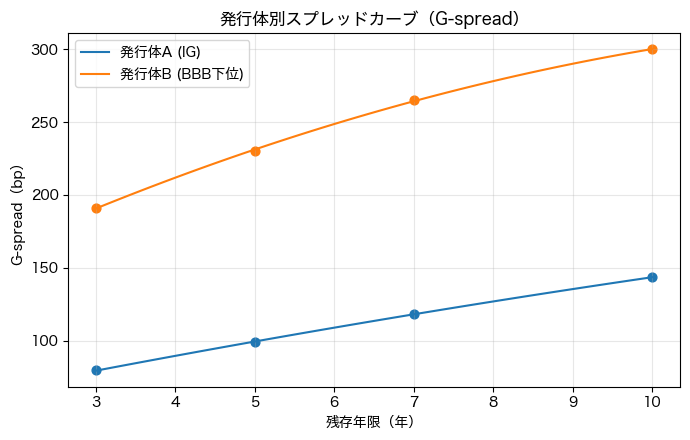

In [4]:
def make_bond(mat_years, coupon):
    """発行4年前スタート・満期 mat_years 年後の半年払い社債を作る（決済日基準）。"""
    mat = dt.date(SETTLE.year + mat_years, SETTLE.month, SETTLE.day)
    iss = dt.date(SETTLE.year - 4, SETTLE.month, SETTLE.day)
    return FixedRateBond(iss, mat, coupon=coupon, frequency=2, convention="ACT/ACT")


def observed_gspread(bond, true_spread, noise_bp=0.0):
    """真のスプレッドで価格を作り、そこからG-spreadを逆算する（noiseで銘柄固有のズレを付与）。"""
    dirty = dirty_from_curve(bond, SETTLE, govt_zc, true_spread + noise_bp / 1e4)
    clean = dirty - bond.accrued(SETTLE)
    y = bond.yield_from_price(clean, SETTLE)
    T = (bond.maturity - SETTLE).days / 365.25
    return T, g_spread(y, interp_rate(TENORS, GOVT_PAR, T))


# 発行体A（IG）: 年限が延びるほど緩やかに拡大。発行体B（BBB下位）: 水準が高く傾きも急。
issuer_true = {
    "発行体A (IG)": {3: 0.0080, 5: 0.0100, 7: 0.0120, 10: 0.0145},
    "発行体B (BBB下位)": {3: 0.0190, 5: 0.0230, 7: 0.0265, 10: 0.0300},
}

fig, ax = plt.subplots(figsize=(7, 4.5))
issuer_curves = {}
for name, spec in issuer_true.items():
    Ts, gss = [], []
    for my, sp in spec.items():
        T, g = observed_gspread(make_bond(my, coupon=0.03 + sp), sp)
        Ts.append(T)
        gss.append(g * 1e4)
    Ts, gss = np.array(Ts), np.array(gss)
    coef = np.polyfit(Ts, gss, 2)
    issuer_curves[name] = coef
    grid = np.linspace(Ts.min(), Ts.max(), 50)
    ax.scatter(Ts, gss, s=40)
    ax.plot(grid, np.polyval(coef, grid), label=name)

ax.set_xlabel("残存年限（年）")
ax.set_ylabel("G-spread（bp）")
ax.set_title("発行体別スプレッドカーブ（G-spread）")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
print("発行体別に、年限が延びるほどスプレッドが拡大する構造が出ています。")

## QuantLib検証

**位置づけの明記**：QuantLib には「G-spread / I-spread / ASW」を1発で返す統一プリミティブは無く、
これらは基準カーブの選び方に依存する定義量です。そこで本節の検証は次の2本立てとし、
**自作スプレッド指標の内部整合と、Zスプレッドの再価格一致を「検証」と位置づけます**。

1. スプレッド計算の土台である**社債利回り（YTM）を QuantLib の `FixedRateBond` と突合**する（外部検証）。
2. 自作スプレッド指標どうしの**内部整合**（G−I がスワップスプレッドに一致、Zスプレッドが真値を復元）を確認する。

In [5]:
import QuantLib as ql

ql_sched = ql.Schedule(
    ql.Date(15, 6, 2024), ql.Date(15, 6, 2029),
    ql.Period(ql.Semiannual), ql.NullCalendar(),
    ql.Unadjusted, ql.Unadjusted,
    ql.DateGeneration.Backward, False,
)
ql_dc = ql.ActualActual(ql.ActualActual.Bond, ql_sched)
qlb = ql.FixedRateBond(0, 100.0, ql_sched, [0.032], ql_dc)

d = ql.Date(15, 6, 2026)
ql.Settings.instance().evaluationDate = d
bp = ql.BondPrice(clean_mkt, ql.BondPrice.Clean)
ql_yield = ql.BondFunctions.bondYield(qlb, bp, ql_dc, ql.Compounded, ql.Semiannual, d)

print(f"bondlab YTM  : {y_corp:.10f}")
print(f"QuantLib YTM : {ql_yield:.10f}")
print(f"差            : {abs(y_corp - ql_yield)*1e4:.4f} bp")
assert abs(y_corp - ql_yield) < 1e-6

bondlab YTM  : 0.0320301245
QuantLib YTM : 0.0320301244
差            : 0.0000 bp


社債利回りが QuantLib と一致するので、スプレッドの土台は健全です。続いて自作指標の内部整合を検査します。

In [6]:
# 内部整合1: G-spread − I-spread は同年限スワップスプレッドに一致する。
swap_spread_T = s_swap_T - y_govt_T
assert abs((gs - is_) - swap_spread_T) < 1e-12

# 内部整合2: Zスプレッドは価格作成に使った真のスプレッドを復元する。
assert abs(zs - assumed_spread) < 1e-8

# 内部整合3: 求めたZスプレッドで割り引くと、市場ダーティ価格に一致する（再価格一致）。
repriced = dirty_from_curve(bond, SETTLE, govt_zc, zs)
assert abs(repriced - dirty_mkt) < 1e-8

print("内部整合チェックをすべて通過しました:")
print(f"  G-I = {(gs-is_)*1e4:.4f} bp  ≈ スワップスプレッド {swap_spread_T*1e4:.4f} bp")
print(f"  Zスプレッド {zs*1e4:.2f} bp ≈ 真値 {assumed_spread*1e4:.2f} bp")
print(f"  Z再価格 {repriced:.6f} ≈ 市場ダーティ {dirty_mkt:.6f}")
print(f"  Z − G の差 = {(zs-gs)*1e4:+.2f} bp（カーブ形状と、基準にパー利回りを使うことによる差）")

内部整合チェックをすべて通過しました:
  G-I = 10.0000 bp  ≈ スワップスプレッド 10.0000 bp
  Zスプレッド 120.00 bp ≈ 真値 120.00 bp
  Z再価格 99.991448 ≈ 市場ダーティ 99.991448
  Z − G の差 = -0.29 bp（カーブ形状と、基準にパー利回りを使うことによる差）


## 実データ適用

### 合成スプレッド時系列の生成（出所の明記）

**データの出所**：ICE BofA US Corporate（IG）/ US High Yield（HY）の OAS 指数は、
水準・景気連動の「形」を参考にしていますが、**指数値そのものは再配布不可**であり、
本ノートはネットワークアクセスを行いません。以下は、現実的な水準と景気サイクルを持つ
**合成系列を、乱数シード固定で自前生成**したものです。実運用では FRED の
`BAMLC0A0CM`（IG OAS）・`BAMLH0A0HYM2`（HY OAS）等を差し替えて使います。

生成の仕組み：景気ストレス係数 $u_t \in [0,1]$（不況期に1へ近づく）を骨格に、
$\text{IG}_t = 110 + 500\,u_t + \varepsilon^{\text{IG}}_t$、
$\text{HY}_t = 350 + 1650\,u_t + \varepsilon^{\text{HY}}_t$（bp）とし、
$\varepsilon$ は AR(1) のノイズです。過去の代表的ストレス期をストレス係数に埋め込みます。

In [7]:
import pandas as pd

rng = np.random.default_rng(7)
months = pd.date_range("2005-01-01", "2025-12-01", freq="MS")
n = len(months)

# 代表的なストレス期（開始, 終了, ピーク強度）。景気後退・信用イベントを近似。
stress_windows = [
    ("2007-08-01", "2009-12-01", 1.00),  # 世界金融危機
    ("2011-07-01", "2012-06-01", 0.35),  # 欧州債務危機
    ("2015-08-01", "2016-02-01", 0.30),  # 資源安・新興国不安
    ("2020-02-01", "2020-08-01", 0.65),  # コロナ・ショック
    ("2022-04-01", "2022-10-01", 0.35),  # 急速な利上げ局面
]

stress = np.zeros(n)
t_idx = np.arange(n)
for start, end, peak in stress_windows:
    s = months.get_indexer([pd.Timestamp(start)])[0]
    e = months.get_indexer([pd.Timestamp(end)])[0]
    mid = (s + e) / 2.0
    half = max((e - s) / 2.0, 1.0)
    # 山形（放物線）でストレスを立ち上げ、ピークで peak に達する。
    bump = peak * np.clip(1 - ((t_idx - mid) / half) ** 2, 0, None)
    stress = np.maximum(stress, bump)


def ar1_noise(sd, rho=0.7):
    e = np.zeros(n)
    for i in range(1, n):
        e[i] = rho * e[i - 1] + rng.normal(0, sd)
    return e


ig_oas = np.clip(110 + 500 * stress + ar1_noise(12.0), 70, None)
hy_oas = np.clip(350 + 1650 * stress + ar1_noise(45.0), 260, None)

spreads = pd.DataFrame({"IG": ig_oas, "HY": hy_oas}, index=months)
print("生成した合成スプレッド（bp）の要約統計:")
display(spreads.describe().round(0))

生成した合成スプレッド（bp）の要約統計:


,IG,HY
count,252.0,252.0
mean,156.0,510.0
std,124.0,415.0
min,70.0,260.0
25%,96.0,311.0
50%,109.0,351.0
75%,127.0,429.0
max,619.0,2077.0


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


金融危機（2008）で最大、コロナ（2020）で次点のスパイクが再現されています。


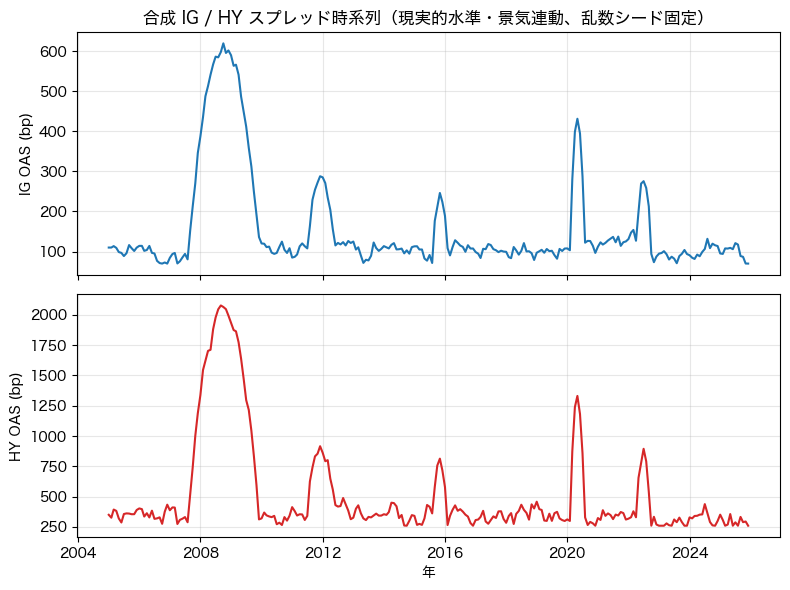

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax[0].plot(spreads.index, spreads["IG"], color="C0")
ax[0].set_ylabel("IG OAS (bp)")
ax[0].set_title("合成 IG / HY スプレッド時系列（現実的水準・景気連動、乱数シード固定）")
ax[0].grid(alpha=0.3)
ax[1].plot(spreads.index, spreads["HY"], color="C3")
ax[1].set_ylabel("HY OAS (bp)")
ax[1].set_xlabel("年")
ax[1].grid(alpha=0.3)
fig.tight_layout()
print("金融危機（2008）で最大、コロナ（2020）で次点のスパイクが再現されています。")

### 景気局面との関係

HY は IG の変動を増幅した形になります（同じストレスに対する係数が大きい）。
HY/IG 比（クオリティスプレッド比）は、リスク選好の温度計として使われます。

In [9]:
ratio = spreads["HY"] / spreads["IG"]
corr = spreads["IG"].corr(spreads["HY"])
print(f"IG と HY の相関: {corr:.3f}")
print(f"HY/IG 比の平均: {ratio.mean():.2f}  レンジ: {ratio.min():.2f}〜{ratio.max():.2f}")

# ストレス期には両者とも拡大するが、HYの拡大幅が大きい。
peak_month = spreads["HY"].idxmax()
print(f"HY 最大月: {peak_month:%Y-%m}  IG={spreads.loc[peak_month,'IG']:.0f}bp  HY={spreads.loc[peak_month,'HY']:.0f}bp")

IG と HY の相関: 0.987
HY/IG 比の平均: 3.32  レンジ: 2.10〜6.19
HY 最大月: 2008-09  IG=598bp  HY=2077bp


### 現在水準の割高・割安

現在（系列の最終月）のスプレッドが、過去分布のどこに位置するかをパーセンタイルとzスコアで測ります。
**低パーセンタイル＝タイト＝割高（クレジットの対価が薄い）**、
**高パーセンタイル＝ワイド＝割安（対価が厚い）** と解釈します。

In [10]:
def richness(series):
    cur = series.iloc[-1]
    pct = (series < cur).mean() * 100
    z = (cur - series.mean()) / series.std()
    verdict = "割高（タイト）" if pct < 33 else ("割安（ワイド）" if pct > 67 else "中立")
    return cur, pct, z, verdict


for name in ["IG", "HY"]:
    cur, pct, z, verdict = richness(spreads[name])
    print(f"{name}: 現在 {cur:.0f}bp  過去パーセンタイル {pct:.0f}%  zスコア {z:+.2f}  → {verdict}")

IG: 現在 70bp  過去パーセンタイル 0%  zスコア -0.69  → 割高（タイト）
HY: 現在 260bp  過去パーセンタイル 0%  zスコア -0.60  → 割高（タイト）


本合成系列では最終月が平常圏にあり、極端な割高・割安は出ていません。実データでも同じ枠組み
（現在値の過去パーセンタイルとzスコア）で、キャリー対価が薄いか厚いかを一次判断できます。
ただしパーセンタイルは局面（不況入り口ではタイトでも将来拡大しうる）を織り込まない点に注意します。

## 演習

1. **IG/HY時系列からの局面判定**：`spreads` の各月を、IG・HY双方の過去パーセンタイルに基づいて
   「平常」「警戒」「ストレス」の3局面に分類する関数を作り、局面別の月数と、直近12か月の局面推移を示せ。
   分類のしきい値（例：両系列が上位25%なら「ストレス」）を自分で決め、根拠を一言添えよ。
2. **同一発行体の複数銘柄で rich/cheap を見る**：ある発行体の複数銘柄（年限違い）からG-spreadを計算し、
   年限に対するスプレッドカーブをフィットせよ。各銘柄の実測スプレッドとフィット値の残差（実測−フィット）を
   求め、正なら割安（cheap）・負なら割高（rich）と判定して表にまとめよ。

解答例は `solutions/S7/sol_0704.py` に置きます。

## 用語集

定義の正は `glossary/07_credit.md`。ここでは初出語の一行要約のみ示します。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| G-spread | G-spread | 社債利回りと同年限国債利回り（補間）の差。単一利回りどうしの差 |
| I-spread | I-spread | 社債利回りと同年限スワップレート（補間）の差。基準をスワップにしたG-spread |
| アセットスワップスプレッド | asset swap spread (ASW) | 社債を固定→変動に交換するアセットスワップで受け取る、変動金利への上乗せ幅 |
| 投資適格 | investment grade (IG) | 格付 BBB−（Baa3）以上の相対的に信用力の高い区分 |
| ハイイールド | high yield (HY) | 格付 BB+（Ba1）以下の投機的等級。高スプレッド・高利回り |